In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# from pass_at_k import pass_at_k_rates_with_sample_variance
# import math
# from pass_at_k import (
#     BetaBinomialPassAtK,
#     NPMLEBinomialPassAtK,
#     BetaMixtureNPMLEPassAtK,
#     KSplicedPassAtK,
#     bootstrap_pass_at_k_ci,
#     kazdan_sampling,
#     uniform_sampling,
# )
# import numpy as np


# def compute(data, k_values, budget_per_problem, random_state=42):
#     rng = np.random.RandomState(random_state)
#     n_problems, n_samples = data.shape

#     data_est = []
#     data_mvue = []
#     for i in range(n_problems):
#         gens = data[i]
#         perm = rng.permutation(n_samples)
#         gens = gens[perm]
#         data_est.append(gens[:budget_per_problem])
#         data_mvue.append(gens[budget_per_problem:])
#     data_mvue = np.asarray(data_mvue)
#     data = {
#         'successes': np.array([gens.sum(dtype=int) for gens in data_est]),
#         'attempts': np.full(n_problems, budget_per_problem, dtype=int),
#     }

#     mvue_pass_at_k, mvue_pass_at_k_var = pass_at_k_rates_with_sample_variance(data_mvue, k_values)

#     est = BetaBinomialPassAtK(verbose=True)

#     est.fit(data['successes'], data['attempts'])
#     est_int = est.predict(k_values, method="integrated", bias_correct=False)
#     est_posterior = est.predict(k_values, method="posterior")

#     est_npmle = NPMLEBinomialPassAtK(verbose=False)
#     est_npmle.fit(data['successes'], data['attempts'])
#     est_npmle_pass = est_npmle.predict(k_values)

#     # est_npmle_plugin = est_npmle.predict(k_values, method="plugin", bias_correct=False)
#     # est_npmle_plugin_bc = est_npmle.predict(k_values, method="plugin", bias_correct=True)

#     # est_beta_mixture_npmle = BetaMixtureNPMLEPassAtK(verbose=False, nu=8.0)
#     # est_beta_mixture_npmle.fit(data['successes'], data['attempts'])
#     # est_beta_mixture_npmle_integrated = est_beta_mixture_npmle.predict(k_values, method='integrated')
#     # est_beta_mixture_npmle_posterior = est_beta_mixture_npmle.predict(k_values, method='posterior')

#     est_npmle_reg = NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
#     est_npmle_reg.fit(data['successes'], data['attempts'])
#     est_npmle_reg_pass = est_npmle_reg.predict(k_values)

#     # est_npmle_reg_plugin = est_npmle_reg.predict(k_values, method="plugin", bias_correct=False)
#     # est_npmle_reg_plugin_bc = est_npmle_reg.predict(k_values, method="plugin", bias_correct=True)

#     # boot_int, lower_int, upper_int = bootstrap_pass_at_k_ci(
#     #     lambda: BetaBinomialPassAtK(verbose=False),
#     #     data['successes'], data['attempts'],
#     #     k_values, n_bootstraps=1000,
#     #     predict_configs=[{"method": "integrated"}]
#     # )

#     est_kspliced = KSplicedPassAtK(
#         BetaBinomialPassAtK(verbose=False),
#         NPMLEBinomialPassAtK(verbose=False),
#     )
#     est_kspliced.fit(data['successes'], data['attempts'])
#     est_kspliced_pass = est_kspliced.predict(k_values)

#     fit = {
#         "estimate": est_int,
#         # "estimate_boot": boot_int,
#         "estimate_posterior": est_posterior,
#         "mvue": mvue_pass_at_k,
#         "mvue_var": mvue_pass_at_k_var,
#         "kspliced": est_kspliced_pass,
#         # "lower_ci": lower_int,
#         # "upper_ci": upper_int,
#         "npmle": est_npmle_pass,
#         # "beta_mixture_integrated": est_beta_mixture_npmle_integrated,
#         # "beta_mixture_posterior": est_beta_mixture_npmle_posterior,
#         # # "efron_g": est_efron_g_pass,
#         # "npmle_plugin": est_npmle_plugin,
#         # "npmle_plugin_bc": est_npmle_plugin_bc,
#         "npmle_reg": est_npmle_reg_pass,
#         # "npmle_reg_plugin": est_npmle_reg_plugin,
#         # "npmle_reg_plugin_bc": est_npmle_reg_plugin_bc,
#     }

#     return fit


In [3]:
from pass_at_k import pass_at_k_rates_with_sample_variance
import math
from pass_at_k import (
    BetaBinomialPassAtK,
    bootstrap_pass_at_k_ci,
    NPMLEBinomialPassAtK,
    MixtureBinomialPassAtK,
    DirichletProcessBetaPassAtK,
    TailStitchedNPMLEPassAtK,
    SplicedPosteriorPassAtK,
    KSplicedPassAtK,
    BetaSmoothedNPMLEPassAtK,
    BetaMixtureNPMLEPassAtK,
)
import numpy as np


def compute(data, k_values, budget_per_problem, random_state=42):
    """Split trials per problem: first `budget` for estimators, rest for MVUE."""
    rng = np.random.RandomState(random_state)
    n_problems, n_samples = data.shape
    b = min(int(budget_per_problem), n_samples // 2)
    if b <= 0:
        raise ValueError(
            f"budget_per_problem must be in [1, {n_samples // 2}]; got {budget_per_problem}"
        )

    data_est = []
    data_mvue = []
    for i in range(n_problems):
        gens = data[i]
        perm = rng.permutation(n_samples)
        gens = gens[perm]
        data_est.append(gens[:b])
        data_mvue.append(gens[b:])
    data_mvue = np.asarray(data_mvue)

    k_values = np.asarray(k_values, dtype=int)
    max_k = data_mvue.shape[1]
    k_values = np.unique(k_values[(k_values >= 1) & (k_values <= max_k)])
    if k_values.size == 0:
        raise ValueError(f"No k values in [1, {max_k}]")

    data = {
        "successes": np.array([gens.sum(dtype=int) for gens in data_est]),
        "attempts": np.full(n_problems, b, dtype=int),
    }

    mvue_pass_at_k, mvue_pass_at_k_var = pass_at_k_rates_with_sample_variance(
        data_mvue, k_values
    )

    est = BetaBinomialPassAtK(verbose=False)

    est.fit(data['successes'], data['attempts'])
    est_int = est.predict(k_values, method="integrated", bias_correct=False)
    est_posterior = est.predict(k_values, method="posterior")

    # est_mixture = MixtureBinomialPassAtK(verbose=False, reg_alpha=0.001)
    # est_mixture.fit(data['successes'], data['attempts'])
    # est_mixture_pass = est_mixture.predict(k_values)

    # est_dp = DirichletProcessBetaPassAtK()
    # est_dp.fit(data['successes'], data['attempts'])
    # est_dp_pass = est_dp.predict(k_values)

    # est_tail = TailStitchedNPMLEPassAtK()
    # est_tail.fit(data['successes'], data['attempts'])
    # est_tail_pass = est_tail.predict(k_values)

    # est_npmle = NPMLEBinomialPassAtK(verbose=False)
    # est_npmle.fit(data['successes'], data['attempts'])
    # est_npmle_pass = est_npmle.predict(k_values)

    # est_npmle_plugin = est_npmle.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_plugin_bc = est_npmle.predict(k_values, method="plugin", bias_correct=True)

    est_beta_mixture_npmle = BetaMixtureNPMLEPassAtK(verbose=True)
    est_beta_mixture_npmle.tune_nu(data['successes'], data['attempts'])
    est_beta_mixture_npmle.fit(data['successes'], data['attempts'])
    est_beta_mixture_npmle = est_beta_mixture_npmle.predict(k_values, method='posterior')

    est_npmle_reg = NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
    est_npmle_reg.fit(data['successes'], data['attempts'])
    est_npmle_reg_pass = est_npmle_reg.predict(k_values)

    # est_npmle_reg_plugin = est_npmle_reg.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_reg_plugin_bc = est_npmle_reg.predict(k_values, method="plugin", bias_correct=True)

    # boot_int, lower_int, upper_int = bootstrap_pass_at_k_ci(
    #     lambda: BetaBinomialPassAtK(verbose=False),
    #     data['successes'], data['attempts'],
    #     k_values, n_bootstraps=200,
    #     predict_configs=[{"method": "integrated"}]
    # )

    # est_spliced = SplicedPosteriorPassAtK(
    #     BetaBinomialPassAtK(verbose=False),
    #     NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
    # )
    # est_spliced.fit(data['successes'], data['attempts'])
    # est_spliced_pass = est_spliced.predict(k_values)

    est_kspliced = KSplicedPassAtK(
        BetaBinomialPassAtK(verbose=False),
        NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001),
    )
    est_kspliced.fit(data['successes'], data['attempts'])
    est_kspliced_pass = est_kspliced.predict(k_values)

    # est_kspliced_beta = KSplicedPassAtK(
    #     BetaBinomialPassAtK(verbose=False),
    #     NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001),
    #     extrapolation="beta_posterior"
    # )
    # est_kspliced_beta.fit(data['successes'], data['attempts'])
    # est_kspliced_beta_pass = est_kspliced_beta.predict(k_values)

    # est_beta_smoothed = BetaSmoothedNPMLEPassAtK(verbose=False)
    # est_beta_smoothed.fit(data['successes'], data['attempts'])
    # est_beta_smoothed_pass = est_beta_smoothed.predict(k_values)


    fit = {
        "k_values": k_values,
        "estimate": est_int,
        # "estimate_boot": boot_int,
        "estimate_posterior": est_posterior,
        "mvue": mvue_pass_at_k,
        "mvue_var": mvue_pass_at_k_var,
        # "mixture_binomial": est_mixture_pass,
        # "dp": est_dp_pass,
        # "tail": est_tail_pass,
        # "lower_ci": lower_int,
        # "upper_ci": upper_int,
        # "npmle": est_npmle_pass,
        # "beta_mixture_integrated": est_beta_mixture_npmle_integrated,
        "beta_mixture": est_beta_mixture_npmle,
        # # "efron_g": est_efron_g_pass,
        # "npmle_plugin": est_npmle_plugin,
        # "npmle_plugin_bc": est_npmle_plugin_bc,
        "npmle_reg": est_npmle_reg_pass,
        # "npmle_reg_plugin": est_npmle_reg_plugin,
        # "npmle_reg_plugin_bc": est_npmle_reg_plugin_bc,
        # "spliced": est_spliced_pass,
        "kspliced": est_kspliced_pass,
        # "beta_smoothed": est_beta_smoothed_pass,
    }

    return fit


In [ ]:
import math
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

DATASET_ID = "ScalingIntelligence/monkey_business"
SPLIT = "test"

import pickle
with open('monkey_business.pkl', 'rb') as f:
    data_dict = pickle.load(f)

# k_values = np.array([1, 2, 5, 10, 20, 50, 100, 200])
# k_values = np.array([1, 2, 5, 10, 20, 50])
k_values = np.arange(1, 1000)
budget_per_problem = 100

cfg_to_data = data_dict

cfg_names = list(cfg_to_data.keys())
n_cfg = len(cfg_names)

# Precompute results per config
results = {}
for cfg in cfg_names:
    oracle_data = cfg_to_data[cfg]['data']
    fit = compute(oracle_data, k_values, budget_per_problem)

    successes_oracle = np.sum(oracle_data, axis=1)
    attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    est_oracle = BetaBinomialPassAtK(verbose=False).fit(successes_oracle, attempts_oracle)
    alpha_oracle, beta_oracle = est_oracle.alpha_, est_oracle.beta_

    p_hat = successes_oracle / attempts_oracle.astype(float)
    p_hat_pos = p_hat[p_hat > 0]

    results[cfg] = {
        "fit": fit,
        "alpha": alpha_oracle,
        "beta": beta_oracle,
        "p_hat_pos": p_hat_pos,
    }


/media/dkp45/ssd/miniconda3/envs/compute/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting CV tuning for nu across candidates: [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
  nu =   0.1 | Mean Val NLL: 31.7423
  nu =   0.2 | Mean Val NLL: 31.3579
  nu =   0.5 | Mean Val NLL: 31.0775
  nu =   1.0 | Mean Val NLL: 30.9396
  nu =   2.0 | Mean Val NLL: 30.9501
  nu =   4.0 | Mean Val NLL: 30.9377
  nu =   8.0 | Mean Val NLL: 30.9530
  nu =  16.0 | Mean Val NLL: 30.9702
  nu =  32.0 | Mean Val NLL: 30.9904
Optimal nu found: 4.0
Starting CV tuning for nu across candidates: [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
  nu =   0.1 | Mean Val NLL: 14.5181
  nu =   0.2 | Mean Val NLL: 14.3043
  nu =   0.5 | Mean Val NLL: 14.1544
  nu =   1.0 | Mean Val NLL: 14.0679
  nu =   2.0 | Mean Val NLL: 14.0222
  nu =   4.0 | Mean Val NLL: 14.0168
  nu =   8.0 | Mean Val NLL: 14.0089
  nu =  16.0 | Mean Val NLL: 13.9734
  nu =  32.0 | Mean Val NLL: 13.9538
Optimal nu found: 32.0
Beta-Mixture NPMLE converged at iteration 3852
Beta-Mixture NPMLE converged at iteration 3852
Sta

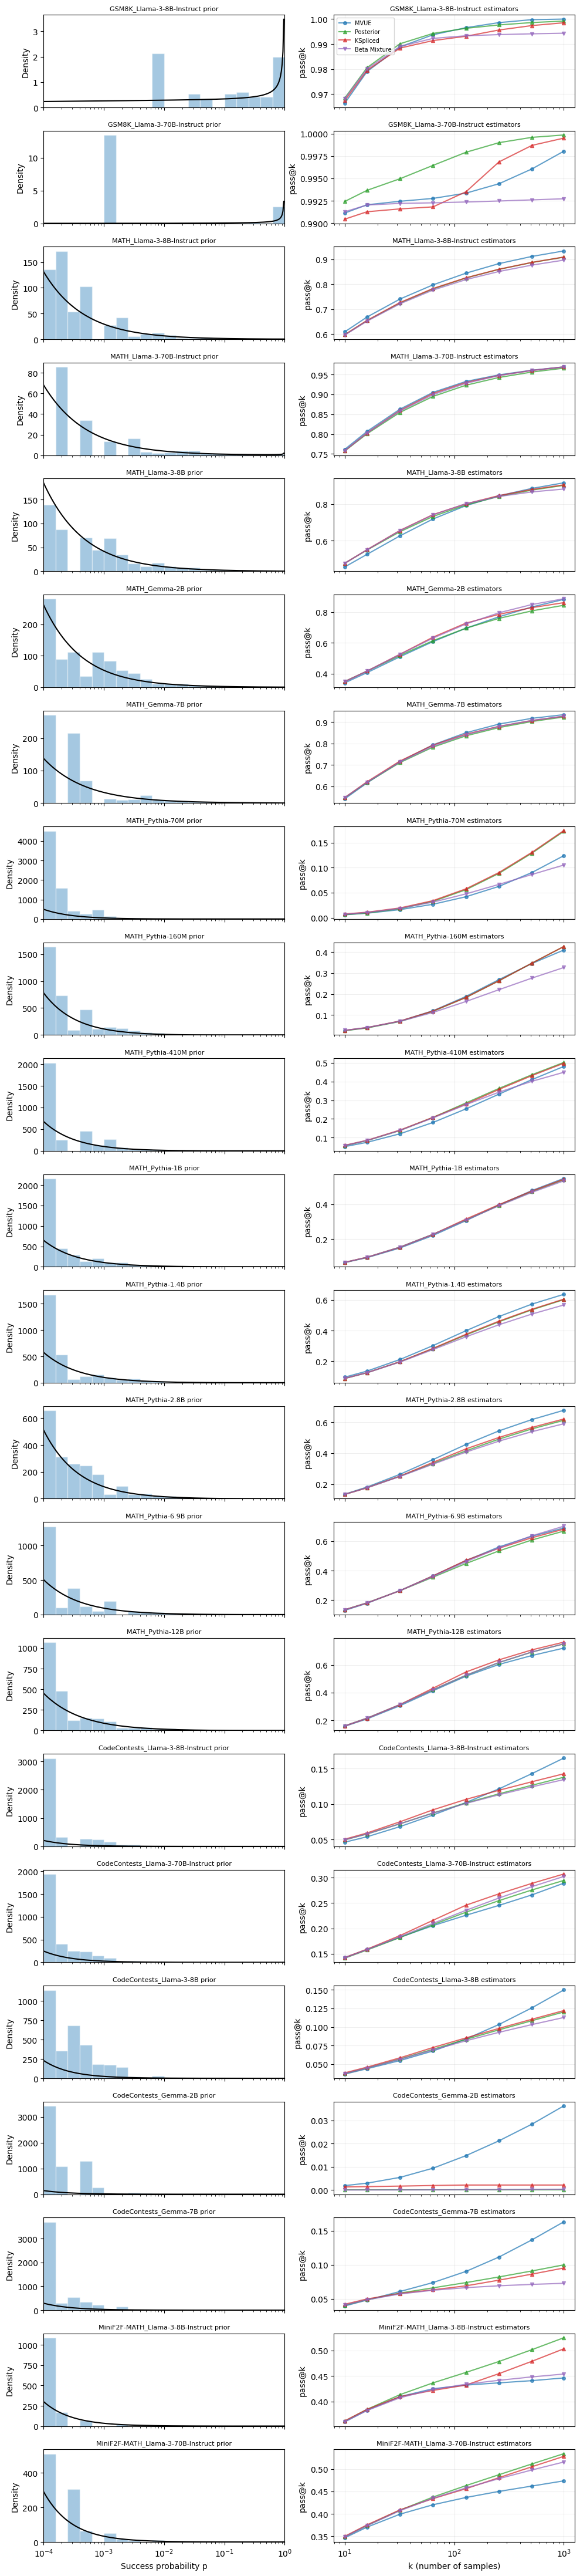

In [8]:
# One big figure with n_cfg rows and 2 columns (20 axes if n_cfg=10)
fig, axes = plt.subplots(n_cfg, 2, figsize=(10, max(6, 2.0 * n_cfg)), sharex="col")

# If only one config, make axes 2D-compatible
if n_cfg == 1:
    axes = np.array([axes])

def _xticks_powers_of_two(k_lo, k_hi):
    """X-axis ticks at powers of 2 in [k_lo, k_hi] for decluttered pass@k plots."""
    k_lo = int(np.ceil(float(k_lo)))
    k_hi = int(np.floor(float(k_hi)))
    ticks = []
    p = 1
    while p <= k_hi:
        if p >= k_lo:
            ticks.append(p)
        p <<= 1
    return ticks


def _mask_k_powers_of_two(k):
    """True at powers of 2 in k, plus always min(k) and max(k)."""
    k = np.asarray(k, dtype=int)
    if k.size == 0:
        return k.astype(bool)
    pow2 = (k >= 1) & ((k & (k - 1)) == 0)
    endpoints = (k == k.min()) | (k == k.max())
    return pow2 | endpoints

x = np.logspace(-4, 0, 300)

for row, cfg in enumerate(cfg_names):
    res = results[cfg]
    fit = res["fit"]
    p_hat_pos = res["p_hat_pos"]

    ax_prior = axes[row, 0]
    ax_est = axes[row, 1]

    # Left: prior (hist + Beta fit)
    ax_prior.hist(
        p_hat_pos,
        bins=np.logspace(-4, 0, 21),
        density=True,
        alpha=0.4,
        color="C0",
        edgecolor="white",
    )
    ax_prior.plot(
        x,
        beta_dist.pdf(x, res["alpha"], res["beta"]),
        "k-",
        linewidth=1.5,
    )
    ax_prior.set_xscale("log")
    if row == n_cfg - 1:
        ax_prior.set_xlabel("Success probability p")
    ax_prior.set_ylabel("Density")
    ax_prior.set_xlim(1e-4, 1)
    ax_prior.set_title(f"{cfg} prior", fontsize=8)

    # Right: estimators vs MVUE
    # ax_est.fill_between(
    #     k_values,
    #     fit["lower_ci"],
    #     fit["upper_ci"],
    #     alpha=0.2,
    #     color="C1",
    # )
    estimator_specs = [
        ("mvue", "MVUE", "o-", "C0"),
        # ("estimate", "Integrated", "s-", "C1"),
        ("estimate_posterior", "Posterior", "^-", "C2"),
        ("kspliced", "KSpliced", "^-", "C3"),
        # ("npmle", "NPMLE", "^-", "C4"),
        ("beta_mixture", "Beta Mixture", "v-", "C4"),
        # # ("efron_g", "Efron G", "^-", "C4"),
        # ("npmle_plugin", "NPMLE Plugin", "o-", "C5"),
        # ("npmle_plugin_bc", "NPMLE Plugin (bias-corrected)", "v-", "C6"),
        # ("npmle_reg", "NPMLE Reg", "^-", "C5"),
        # ("npmle_reg_plugin", "NPMLE Reg Plugin", "o-", "C8"),
        # ("npmle_reg_plugin_bc", "NPMLE Reg Plugin (bias-corrected)", "v-", "C9"),
    ]

    # for key, label, style, color in estimator_specs:
    #     if key in fit:
    #         ax_est.plot(
    #             k_values,
    #             fit[key],
    #             style,
    #             color=color,
    #             linewidth=1.5,
    #             markersize=4,
    #             label=label,
    #         )
    for key, label, style, color in estimator_specs:
        if key in fit:
            k_plot = np.array(fit["k_values"])
            y_series = np.asarray(fit[key], dtype=float)
            m_k = _mask_k_powers_of_two(k_plot)
            ax_est.set_xscale("log")
            ax_est.plot(
                k_plot[m_k],
                y_series[m_k],
                style,
                color=color,
                linewidth=1.5,
                markersize=4,
                label=label,
                alpha=0.7,
            )
    
    # ax_est.set_ylim(0.0, 1.0)
    ax_est.set_xticks(_xticks_powers_of_two(k_plot.min(), k_plot.max()))
    ax_est.set_xscale("log")
    if row == n_cfg - 1:
        ax_est.set_xlabel("k (number of samples)")
    ax_est.set_ylabel("pass@k")
    ax_est.grid(True, alpha=0.2)
    ax_est.set_title(f"{cfg} estimators", fontsize=8)

# Only put legend on the first estimator axis to keep things readable
first_est_ax = axes[0, 1]
handles, labels = first_est_ax.get_legend_handles_labels()
first_est_ax.legend(handles, labels, fontsize=7, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

K_MAX = 100

cfg_to_data = data_dict

# estimator_name -> {cfg -> WRMSE}
estimator_errors = {}

for cfg, oracle_data in cfg_to_data.items():
    oracle_data = oracle_data['data']
    # 1) Estimator curves on sampled data
    # fit = compute(oracle_data, k_values, total_budget, sampler="uniform")
    fit = results[cfg]['fit']
    k_plot = np.asarray(fit["k_values"])
    k_mask = (k_plot >= 1) & (k_plot <= K_MAX)
    mvue_curve = np.asarray(fit["mvue"], dtype=float)[k_mask]
    variance_curve = np.asarray(fit["mvue_var"], dtype=float)[k_mask]
    # # 2) Inverse-variance weighting curve from oracle p_true
    # successes_oracle = np.sum(oracle_data, axis=1)
    # attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    # p_true = successes_oracle / attempts_oracle.astype(float)

    # n_tasks = len(p_true)
    # m_samples_per_task = total_budget / n_tasks

    # k_vec = k_values[:, None]
    # p_vec = p_true[None, :]
    # variance_curve = (k_vec**2 / (n_tasks**2 * m_samples_per_task)) * np.sum(
    #     p_vec * (1.0 - p_vec) ** (2 * k_vec - 1),
    #     axis=1,
    # )
    # variance_curve = variance_curve + 1e-12

    # 3) WRMSE for each estimator in fit (except MVUE itself)
    for est_name, est_curve in fit.items():
        if est_name in ["mvue", "lower_ci", "upper_ci", "estimate_boot"]:
            continue
        est_curve = np.asarray(est_curve, dtype=float)[k_mask]
        # wmse = np.mean(((est_curve - mvue_curve) ** 2) / variance_curve)
        wmse = np.mean(((est_curve - mvue_curve) ** 2))
        wrmse = float(np.sqrt(wmse))
        estimator_errors.setdefault(est_name, {})[cfg] = wrmse

# ---------- Reporting (clean aligned table) ----------
error_df = pd.DataFrame(estimator_errors).sort_index()
error_df.index.name = "config"

# Pretty column names
error_df = error_df.rename(columns={c: f"WRMSE[{c}]" for c in error_df.columns})

# Per-config table
display(error_df.style.format("{:.4f}"))

# Summary table (mean/std across configs)
summary_df = pd.DataFrame({
    "mean": error_df.mean(axis=0),
    "std": error_df.std(axis=0),
    "min": error_df.min(axis=0),
    "max": error_df.max(axis=0),
}).sort_values("mean")

display(summary_df.style.format("{:.4f}"))

# If you need plain text output too:
print("\nPer-config WRMSE table:\n")
print(error_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nEstimator summary (sorted by mean WRMSE):\n")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

,WRMSE[k_values],WRMSE[estimate],WRMSE[estimate_posterior],WRMSE[mvue_var],WRMSE[beta_mixture],WRMSE[npmle_reg],WRMSE[kspliced]
config,,,,,,,
CodeContests_Gemma-2B,579.7968,0.0274,0.0274,0.0273,0.0271,0.0239,0.0254
CodeContests_Gemma-7B,579.6982,0.0461,0.0445,0.1311,0.0637,0.0634,0.0488
CodeContests_Llama-3-70B-Instruct,579.5865,0.0098,0.0081,0.2585,0.0142,0.0767,0.0207
CodeContests_Llama-3-8B,579.7083,0.0187,0.0183,0.1207,0.0234,0.0291,0.0168
CodeContests_Llama-3-8B-Instruct,579.6940,0.0173,0.0170,0.1369,0.0192,0.0154,0.0131
GSM8K_Llama-3-70B-Instruct,578.9564,0.0045,0.0035,0.9957,0.0035,0.0033,0.0021
GSM8K_Llama-3-8B-Instruct,578.9538,0.0005,0.0010,0.9985,0.0051,0.0062,0.0024
MATH_Gemma-2B,579.0907,0.0406,0.0252,0.8023,0.0178,0.0249,0.0173
MATH_Gemma-7B,579.0230,0.0253,0.0137,0.8983,0.0090,0.0060,0.0089


,mean,std,min,max
WRMSE[kspliced],0.0211,0.0153,0.0013,0.0488
WRMSE[estimate_posterior],0.0235,0.0168,0.0010,0.0580
WRMSE[beta_mixture],0.0249,0.0216,0.0022,0.0735
WRMSE[estimate],0.0262,0.0171,0.0005,0.0638
WRMSE[npmle_reg],0.0441,0.0445,0.0033,0.1832
WRMSE[mvue_var],0.5268,0.3216,0.0273,0.9985
WRMSE[k_values],579.3455,0.2816,578.9538,579.7968



Per-config WRMSE table:

                                   WRMSE[k_values]  WRMSE[estimate]  WRMSE[estimate_posterior]  WRMSE[mvue_var]  WRMSE[beta_mixture]  WRMSE[npmle_reg]  WRMSE[kspliced]
config                                                                                                                                                                 
CodeContests_Gemma-2B                     579.7968           0.0274                     0.0274           0.0273               0.0271            0.0239           0.0254
CodeContests_Gemma-7B                     579.6982           0.0461                     0.0445           0.1311               0.0637            0.0634           0.0488
CodeContests_Llama-3-70B-Instruct         579.5865           0.0098                     0.0081           0.2585               0.0142            0.0767           0.0207
CodeContests_Llama-3-8B                   579.7083           0.0187                     0.0183           0.1207               0.0234  

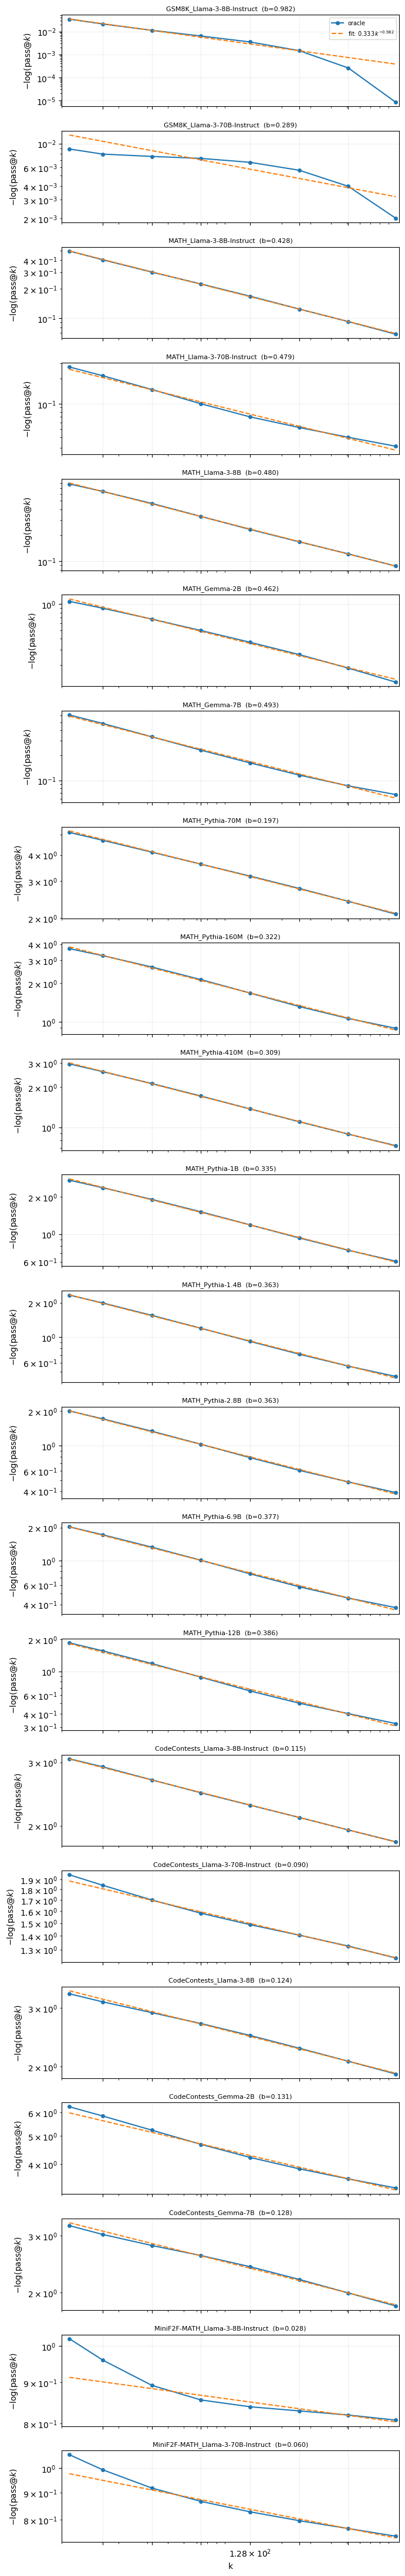

In [7]:
from scipy.optimize import curve_fit

# -log(pass@k) from full oracle data (do not overwrite `results`)
from pass_at_k import pass_at_k_rates
neg_log_results = {}
for cfg in cfg_names:
    oracle_data = cfg_to_data[cfg]["data"]
    pass_at_k = pass_at_k_rates(oracle_data, k_values)  # or your (1-(1-p)**k).mean() formula
    neg_log_results[cfg] = -np.log(np.clip(pass_at_k, 1e-12, 1.0))

def power_law(k, a, b):
    """y = a * k^{-b}"""
    k = np.asarray(k, dtype=float)
    return a * np.power(k, -b)

def fit_power_law_neg_log(k, neg_log_pass_at_k):
    k = np.asarray(k, dtype=float)
    y = np.asarray(neg_log_pass_at_k, dtype=float)
    mask = (k > 0) & (y > 0) & np.isfinite(y)
    k_fit, y_fit = k[mask], y[mask]

    # log(y) = log(a) - b*log(k)
    slope, intercept = np.polyfit(np.log(k_fit), np.log(y_fit), 1)
    b0 = -slope
    a0 = np.exp(intercept)

    (a, b), _ = curve_fit(
        power_law,
        k_fit,
        y_fit,
        p0=(a0, b0),
        bounds=([1e-12, 0.0], [np.inf, np.inf]),
        maxfev=10_000,
    )
    return float(a), float(b)

PASSK_PLOT_POW2_K_ONLY = True

# --- after neg_log_results is built ---
fig, axes = plt.subplots(n_cfg, 1, figsize=(7, 2.0 * n_cfg), sharex=True)
axes = np.atleast_1d(axes)

k_plot = np.asarray(k_values, dtype=float)
k_fine = np.geomspace(k_plot.min(), k_plot.max(), 200)  # smooth line on log-x

for row, cfg in enumerate(cfg_names):
    ax = axes[row]
    y = np.asarray(neg_log_results[cfg], dtype=float)

    a, b = fit_power_law_neg_log(k_plot, y)
    y_hat = power_law(k_fine, a, b)

    if PASSK_PLOT_POW2_K_ONLY:
        m = _mask_k_powers_of_two(k_plot)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.plot(k_plot[m], y[m], "o-", color="C0", label="oracle", linewidth=1.5, markersize=4)
    else:
        ax.plot(k_plot, y, "o-", color="C0", label="oracle", linewidth=1.5)

    ax.plot(
        k_fine,
        y_hat,
        "--",
        color="C1",
        linewidth=1.5,
        label=rf"fit: ${a:.3g}\,k^{{-{b:.3g}}}$",
    )

    ax.set_xlim(k_plot.min() * 0.9, k_plot.max() * 1.05)
    ax.set_xticks(_xticks_powers_of_two(k_plot.min(), k_plot.max()))
    ax.set_ylabel(r"$-\log(\mathrm{pass@}k)$")
    ax.grid(True, alpha=0.2)
    ax.set_title(f"{cfg}  (b={b:.3f})", fontsize=8)
    if row == 0:
        ax.legend(fontsize=7, loc="best")
    if row == n_cfg - 1:
        ax.set_xlabel("k")

plt.tight_layout()
plt.show()